**รายละเอียดโจทย์การบ้าน: Hybrid Multi-Agent System**

ในโจทย์นี้ นักศึกษาจะได้ออกแบบและทดลองสร้างระบบ Multi-Agent ที่ผสมผสานความสามารถจากหลาย ๆ ตัวแทน ดังนี้

1. **ReAct (Research) Agent**

   * ใช้ฟังก์ชัน ` เพื่อดึงข้อมูลจาก Wikipedia ต`search_wikipedia(term)ามคำค้น

2. **Coding Agent**

   * ใช้ฟังก์ชัน `run_python_code(code)` เพื่อรันโค้ด Python จริง และส่งผลลัพธ์กลับมา
   * หลังรันแล้ว ให้สะท้อนผลลัพธ์ (self-reflection) เพื่อปรับปรุงโค้ดหรือคำอธิบายให้สมบูรณ์ยิ่งขึ้น
3. **Mixture-of-Agents Orchestrator**

   * ใช้ฟังก์ชัน `mixture_of_agents(user_prompt, agent_roles)`
   * กำหนดบทบาท (roles) ของ Proposer Agents อย่างน้อย 2 บทบาท (เช่น “Data Scientist”, “frontend developer”, “backend engineer”, “UX designer” เป็นต้น)
   * รวบรวม (aggregate) คำตอบจากแต่ละ Proposer แล้วสังเคราะห์ผลลัพธ์ออกมาเป็นคำตอบเดียว

> **สิ่งที่ต้องส่ง**
> * โค้ด Python ที่ประกอบด้วยการเรียกใช้ทั้ง `research_agent()`, `coding_agent()`, และ `mixture_of_agents()`


---

#### ตัวอย่างคำถามจำนวน 5 ข้อ (ในรูปแบบ Python list) สำหรับทดสอบระบบ

```python
questions = [
    # 1. หัวข้อ AI เบื้องต้น:
    "สรุปแนวคิดหลักของ 'Reinforcement Learning' จาก Wikipedia แล้วสร้างกราฟแสดง reward function ด้วย Python พร้อมสะท้อนผลลัพธ์ทุกขั้นตอน",

    # 2. วิเคราะห์ข้อมูลจริง:
    "ใช้ Research Agent ดึงข้อมูลสถิติ COVID-19 รายวันจาก Wikipedia จากนั้น Coding Agent คำนวณค่า moving average ของยอดผู้ติดเชื้อ 7 วัน และ Mixture-of-Agents ให้บทบาท 'Epidemiologist' และ 'Data Analyst' เสนอแนวทางจัดการข้อมูล",

    # 3. เปรียบเทียบอัลกอริทึม:
    "เปรียบเทียบเวลาในการรันอัลกอริทึม 'Quick Sort' และ 'Merge Sort' ด้วย Coding Agent พร้อม Self-Reflection ว่าการเลือกใช้โครงสร้างข้อมูลใดเหมาะสมกว่า และให้ Mixture-of-Agents สะท้อนมุมมองของ 'Algorithm Theorist' กับ 'Benchmark Specialist'",

    # 4. ออกแบบ Chatbot ง่าย ๆ:
    "สร้างระบบ Chatbot เบื้องต้น: Research Agent ค้นหา FAQ จาก Wikipedia, Coding Agent เขียนโค้ด Flask ให้สามารถรับข้อความและตอบกลับ, Mixture-of-Agents ให้บทบาท 'UX Designer' และ 'Backend Engineer' วิเคราะห์การทำงาน และสะท้อนปรับปรุง UX/UI",

    # 5. วิเคราะห์ชุดข้อมูล Titanic:
    "Research Agent สรุปที่มาของชุดข้อมูล Titanic จาก Wikipedia, Coding Agent โหลดข้อมูลและคำนวณอัตราการรอดชีวิตตามเพศและชั้นผู้โดยสาร พร้อม self-reflection, Mixture-of-Agents ให้บทบาท 'Statistician' และ 'Data Engineer' สรุปผลเชิงตีความ"
]
```

> แต่ละโจทย์จะต้องรันผ่านฟังก์ชัน
>
> ```python
> result = multi_agent_system(question)
> ```
>
> และ
>
> ```python
> final = mixture_of_agents(question, ["Role1", "Role2"])
> ```
>
> พร้อมแสดง output ทุกขั้นตอนและข้อคิดเห็น (reflection) ของแต่ละ agent ให้ครบถ้วน เพื่อให้เห็นภาพการทำงานร่วมกันของระบบ Multi-Agent Hybrid นี้อย่างชัดเจน


In [40]:
import IPython
import sys

def clean_notebook():
    IPython.display.clear_output(wait=True)
    print("Notebook cleaned.")

!pip install openai wikipedia sympy requests -q

# Clean up the notebook
clean_notebook()


Notebook cleaned.


In [41]:
import os
from openai import OpenAI
import json
from dotenv import load_dotenv

# Load environment variables
load_dotenv()

True

In [42]:
import os
from openai import OpenAI
import wikipedia
from sympy import sympify
import requests
from datetime import date
import random
import json
from io import StringIO
import sys

# Set up OpenAI client
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
model_name = "gpt-4o"  # Using 'gpt-4o' as a stand-in; change if needed to 'gpt-4.1' or another model
# Set up OpenAI client

In [43]:
import wikipedia

def search_wikipedia(term):
    try:
        result = wikipedia.summary(term, sentences=5)
        return result
    except Exception as e:
        return "Error: " + str(e)

def run_python_code(code):
    old_stdout = sys.stdout
    redirected_output = sys.stdout = StringIO()
    try:
        exec(code)
        sys.stdout = old_stdout
        return redirected_output.getvalue()
    except Exception as e:
        sys.stdout = old_stdout
        return str(e)

## Research Agent Function

In [44]:
import json

# ---------- Research Agent ----------
def research_agent(query):
    messages = [
        {"role": "system", "content": "You are a research agent. Use the search_wikipedia tool to find information from Wikipedia if needed. Summarize the key points."},
        {"role": "user", "content": query}
    ]
    
    tools = [
        {
            "type": "function",
            "function": {
                "name": "search_wikipedia",
                "description": "Search Wikipedia for information on a given term.",
                "parameters": {
                    "type": "object",
                    "properties": {
                        "term": {"type": "string", "description": "The search term for Wikipedia."}
                    },
                    "required": ["term"]
                }
            }
        }
    ]
    
    response = client.chat.completions.create(
        model="gpt-4o",
        messages=messages,
        tools=tools,
        tool_choice="auto"
    )
    
    choice = response.choices[0].message

    # ตรวจสอบว่ามี tool_call หรือไม่
    if hasattr(choice, "tool_calls") and choice.tool_calls:
        tool_call = choice.tool_calls[0]
        if tool_call.function.name == "search_wikipedia":
            args = json.loads(tool_call.function.arguments)
            term = args["term"]
            wiki_result = search_wikipedia(term)  # ฟังก์ชัน mock ของคุณ

            # Append tool response
            messages.append({
                "role": "assistant",
                "content": choice.content or "",
                "tool_calls": [tool_call]
            })
            messages.append({
                "role": "tool",
                "tool_call_id": tool_call.id,
                "name": tool_call.function.name,
                "content": wiki_result
            })

            # เรียก model อีกครั้งเพื่อ summarize/reflection
            response2 = client.chat.completions.create(
                model="gpt-4o",
                messages=messages
            )
            return response2.choices[0].message.content
    # กรณีไม่เรียก tool
    return choice.content

## Coding Agent Function

In [45]:
def coding_agent(task):
    messages = [
        {"role": "system", "content": "You are a coding agent. Write Python code to solve the task, run it using the tool if needed, and reflect on the output."},
        {"role": "user", "content": task}
    ]
    
    tools = [
        {
            "type": "function",
            "function": {
                "name": "run_python_code",
                "description": "Execute Python code and return the output.",
                "parameters": {
                    "type": "object",
                    "properties": {
                        "code": {"type": "string", "description": "The Python code to execute."}
                    },
                    "required": ["code"]
                }
            }
        }
    ]
    
    # Generate the initial answer using LLM
    initial_response = llm_generator(messages)
    
    tools[0]["function"]["parameters"]["properties"]["code"]["description"] = initial_response
    
    # Run the code and execute the Python script
    response = client.chat.completions.create(
        model="gpt-4o",
        messages=messages,
        tools=tools,
        tool_choice="auto"
    )
    
    choice = response.choices[0].message
    
    if hasattr(choice, "tool_calls") and choice.tool_calls:
        tool_call = choice.tool_calls[0]
        if tool_call.function.name == "run_python_code":
            args = json.loads(tool_call.function.arguments)
            code = args["code"]
            try:
                # Run the Python code
                code_output = run_python_code(code)  # Run the code here
                reflection = "The code ran successfully. The output was as expected."  # Self-reflection after successful output

            except Exception as e:
                code_output = str(e)
                reflection = f"An error occurred: {code_output}. Let's reflect on the issue and adjust the code accordingly."
            
            # Generate feedback using the reflect agent
            feedback = reflect_agent(code_output)  # Analyzing the result of the execution
            
            # Combine feedback into the message flow
            messages.append({
                "role": "assistant",
                "content": choice.content or "",
                "tool_calls": [tool_call]
            })
            messages.append({
                "role": "tool",
                "tool_call_id": tool_call.id,
                "name": tool_call.function.name,
                "content": code_output
            })
            messages.append({
                "role": "assistant",
                "content": reflection
            })
            messages.append({
                "role": "assistant",
                "content": f"Reflection Feedback: {feedback}"  # Include the reflection feedback
            })

            # Final reflection response
            response2 = client.chat.completions.create(
                model="gpt-4o",
                messages=messages
            )
            return response2.choices[0].message.content
    
    return choice.content


In [46]:
# # ---------- Coding Agent ----------
# def coding_agent(task):
#     messages = [
#         {"role": "system", "content": "You are a coding agent. Write Python code to solve the task, run it using the tool if needed, and reflect on the output."},
#         {"role": "user", "content": task}
#     ]
    
#     tools = [
#         {
#             "type": "function",
#             "function": {
#                 "name": "run_python_code",
#                 "description": "Execute Python code and return the output.",
#                 "parameters": {
#                     "type": "object",
#                     "properties": {
#                         "code": {"type": "string", "description": "The Python code to execute."}
#                     },
#                     "required": ["code"]
#                 }
#             }
#         }
#     ]
    
#     response = client.chat.completions.create(
#         model="gpt-4o",
#         messages=messages,
#         tools=tools,
#         tool_choice="auto"
#     )
    
#     choice = response.choices[0].message

#     # ตรวจสอบ tool_call
#     if hasattr(choice, "tool_calls") and choice.tool_calls:
#         tool_call = choice.tool_calls[0]
#         if tool_call.function.name == "run_python_code":
#             args = json.loads(tool_call.function.arguments)
#             code = args["code"]
#             code_output = run_python_code(code)  # ฟังก์ชัน mock ของคุณ

#             # Append tool response
#             messages.append({
#                 "role": "assistant",
#                 "content": choice.content or "",
#                 "tool_calls": [tool_call]
#             })
#             messages.append({
#                 "role": "tool",
#                 "tool_call_id": tool_call.id,
#                 "name": tool_call.function.name,
#                 "content": code_output
#             })

#             # เรียก model อีกครั้งเพื่อ reflection
#             response2 = client.chat.completions.create(
#                 model="gpt-4o",
#                 messages=messages
#             )
#             return response2.choices[0].message.content
#     # กรณีไม่เรียก tool
#     return choice.content

## Multi-Agent System Function

In [47]:
def multi_agent_system(question):
    print("Research Agent working...")
    research_result = research_agent(question)
    print("Research Result:", research_result)
    
    print("\nCoding Agent working...")
    coding_task = f"Based on this research: {research_result}\nSolve or analyze the question with Python code if applicable: {question}"
    coding_result = coding_agent(coding_task)
    print("Coding Result:", coding_result)
    
    return coding_result

## Reflect

In [48]:
# Cell 2: Define the LLM Generator Function
# This function acts as the "answer agent". It takes a list of messages and generates a response using the LLM.
# The messages should include a system prompt like: "You are a helpful assistant that thinks step by step."
# It can also include previous conversations or feedback for improvement.

def llm_generator(messages):
    """
    Generate a response from the LLM based on the input messages.
    
    Args:
    messages (list): List of message dictionaries, e.g., [{"role": "system", "content": "..."}, {"role": "user", "content": "..."}]
    
    Returns:
    str: The generated response content.
    """
    response = client.chat.completions.create(
        model=model_name,
        messages=messages,
        temperature=0.1,  # Adjust temperature for creativity

    )
    return response.choices[0].message.content

In [49]:

def reflect_agent(answer):
    """
    Analyze the given answer using the reflective prompt and return the feedback.
    
    Args:
    answer (str): The answer to reflect on.
    
    Returns:
    str: The reflection feedback as a string.
    """
    reflect_prompt = (
        f"คุณเป็นผู้เชี่ยวชาญในการประเมินคำตอบ กรุณาวิเคราะห์คำตอบต่อไปนี้ in thai:\n"
        f"- 'completeness': ประเมินความครบถ้วนของคำตอบ (คะแนน 1-10)\n"
        f"- 'accuracy': ประเมินความถูกต้องของคำตอบ (คะแนน 1-10)\n"
        f"- 'clarity': ประเมินความชัดเจนของคำตอบ (คะแนน 1-10)\n"
        f"- 'strengths': จุดแข็งของคำตอบ\n"
        f"- 'weaknesses': จุดอย่อนของคำตอบ\n"
        f"- 'missing_aspects': สิ่งที่ขาดหายไปในคำตอบ\n"
        f"- 'improvement_suggestions': ข้อเสนอแนะเพื่อปรับปรุงคำตอบ\n\n"
        f"คำตอบ: {answer}\n"
    )
    
    # Messages for the reflect function
    messages = [
        {"role": "system", "content": reflect_prompt}
    ]
    
    # Call the LLM to generate the reflection (using the same generator function for simplicity)
    feedback = llm_generator(messages)
    return feedback

## Mixture-of-Agents

In [50]:
def proposer_agent(user_prompt, agent_role, model_name="gpt-4o"):
    """
    Generates a response from an AI agent with a specific role.
    
    Parameters:
    - user_prompt (str): The user's query or question.
    - agent_role (str): The role or perspective of the agent (e.g., "Creative Writer").
    - model_name (str): The OpenAI model to use.
    
    Returns:
    - str: The agent's response.
    """
    # Define the system prompt to guide the agent's behavior
    system_prompt = f"You are a {agent_role}. Provide a detailed and relevant response to the user's query."
    
    try:
        # Call the OpenAI API
        completion = client.chat.completions.create(
            model=model_name,
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt},
            ]
        )
        # Extract and return the agent's response
        response = completion.choices[0].message.content
        return response
    except Exception as e:
        print(f"Error in proposer_agent: {e}")
        return "Error generating response."


In [51]:
def aggregator_agent(proposer_responses, user_prompt, model_name="gpt-4o"):
    """
    Combines responses from proposer agents into a single, refined response.
    
    Parameters:
    - proposer_responses (list): List of responses from proposer agents.
    - user_prompt (str): The original user query.
    - model_name (str): The OpenAI model to use.
    
    Returns:
    - str: The final aggregated response.
    """
    # Combine all proposer responses into a single string
    combined_input = "\n\n".join([f"Agent {i+1} Response:\n{resp}" for i, resp in enumerate(proposer_responses)])
    
    # Define the system prompt for the aggregator
    system_prompt = (
        "You are an expert summarizer and synthesizer. Your task is to take the following responses "
        "from multiple agents and combine them into a single, coherent, and comprehensive answer "
        "to the user's query. Ensure the response is clear, concise, and addresses the query effectively."
    )
    
    # Create the prompt for the aggregator
    aggregator_prompt = (
        f"User Query: {user_prompt}\n\n"
        f"Agent Responses:\n{combined_input}\n\n"
        "Synthesize these responses into a single answer."
    )
    
    try:
        # Call the OpenAI API
        completion = client.chat.completions.create(
            model=model_name,
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": aggregator_prompt},
            ]
        )
        # Extract and return the aggregated response
        response = completion.choices[0].message.content
        return response
    except Exception as e:
        print(f"Error in aggregator_agent: {e}")
        return "Error generating aggregated response."

In [52]:
def mixture_of_agents(user_prompt, agent_roles, model_name="gpt-4o"):
    """
    Runs the Mixture-of-Agents system to generate a final response.
    
    Parameters:
    - user_prompt (str): The user's query or question.
    - agent_roles (list): List of roles for proposer agents (e.g., ["Creative Writer", "Fact Checker"]).
    - model_name (str): The OpenAI model to use.
    
    Returns:
    - str: The final aggregated response.
    """
    print(f"Processing query: {user_prompt}")
    
    # Step 1: Collect responses from proposer agents
    proposer_responses = []
    for role in agent_roles:
        print(f"Generating response from {role}...")
        response = proposer_agent(user_prompt, role, model_name)
        if response:
            print(f"Response from {role}: {response}")
            print("\n====================================================================\n")
        else:
            print(f"No response generated by {role}.")
        
        proposer_responses.append(response)
    
    # Step 2: Aggregate the responses
    print("Aggregating responses...")
    final_response = aggregator_agent(proposer_responses, user_prompt, model_name)
    
    return final_response

## ทำโจทย์

In [53]:
system_prompt = "You are a helpful assistant that uses tools to answer questions."

In [54]:
questions = [
    # 1. หัวข้อ AI เบื้องต้น:
    # "สรุปแนวคิดหลักของ 'Reinforcement Learning' จาก Wikipedia แล้วสร้างกราฟแสดง reward function ด้วย Python พร้อมสะท้อนผลลัพธ์ทุกขั้นตอน",
    # 2. วิเคราะห์ข้อมูลจริง:
    "ใช้ Research Agent ดึงข้อมูลสถิติ COVID-19 รายวันจาก Wikipedia จากนั้น Coding Agent คำนวณค่า moving average ของยอดผู้ติดเชื้อ 7 วัน และ Mixture-of-Agents ให้บทบาท 'Epidemiologist' และ 'Data Analyst' เสนอแนวทางจัดการข้อมูล",
    # # 3. เปรียบเทียบอัลกอริทึม:
    # "เปรียบเทียบเวลาในการรันอัลกอริทึม 'Quick Sort' และ 'Merge Sort' ด้วย Coding Agent พร้อม Self-Reflection ว่าการเลือกใช้โครงสร้างข้อมูลใดเหมาะสมกว่า และให้ Mixture-of-Agents สะท้อนมุมมองของ 'Algorithm Theorist' กับ 'Benchmark Specialist'",
    # # 4. ออกแบบ Chatbot ง่าย ๆ:
    # "สร้างระบบ Chatbot เบื้องต้น: Research Agent ค้นหา FAQ จาก Wikipedia, Coding Agent เขียนโค้ด Flask ให้สามารถรับข้อความและตอบกลับ, Mixture-of-Agents ให้บทบาท 'UX Designer' และ 'Backend Engineer' วิเคราะห์การทำงาน และสะท้อนปรับปรุง UX/UI",
    # # 5. วิเคราะห์ชุดข้อมูล Titanic:
    # "Research Agent สรุปที่มาของชุดข้อมูล Titanic จาก Wikipedia, Coding Agent โหลดข้อมูลและคำนวณอัตราการรอดชีวิตตามเพศและชั้นผู้โดยสาร พร้อม self-reflection, Mixture-of-Agents ให้บทบาท 'Statistician' และ 'Data Engineer' สรุปผลเชิงตีความ"
]

--------------------------------------------------

 Question: ใช้ Research Agent ดึงข้อมูลสถิติ COVID-19 รายวันจาก Wikipedia จากนั้น Coding Agent คำนวณค่า moving average ของยอดผู้ติดเชื้อ 7 วัน และ Mixture-of-Agents ให้บทบาท 'Epidemiologist' และ 'Data Analyst' เสนอแนวทางจัดการข้อมูล
Research Agent working...
Research Result: Wikipedia provides comprehensive cumulative statistics on COVID-19, including monthly death numbers by country and worldwide maps and timeline graphs of daily and weekly deaths. For real-time daily updates on cases, deaths, and death rates, the article recommends referring to specific resources like the 'COVID-19 pandemic death rates by country'.

### Coding Agent

To calculate a 7-day moving average of daily COVID-19 cases, you can perform the following steps in a coding script, assuming you have daily case data:

1. **Read the Data**: Load daily case data into a script, typically from a CSV or data frame.

2. **Calculate Moving Average**:
   - Use rolling window

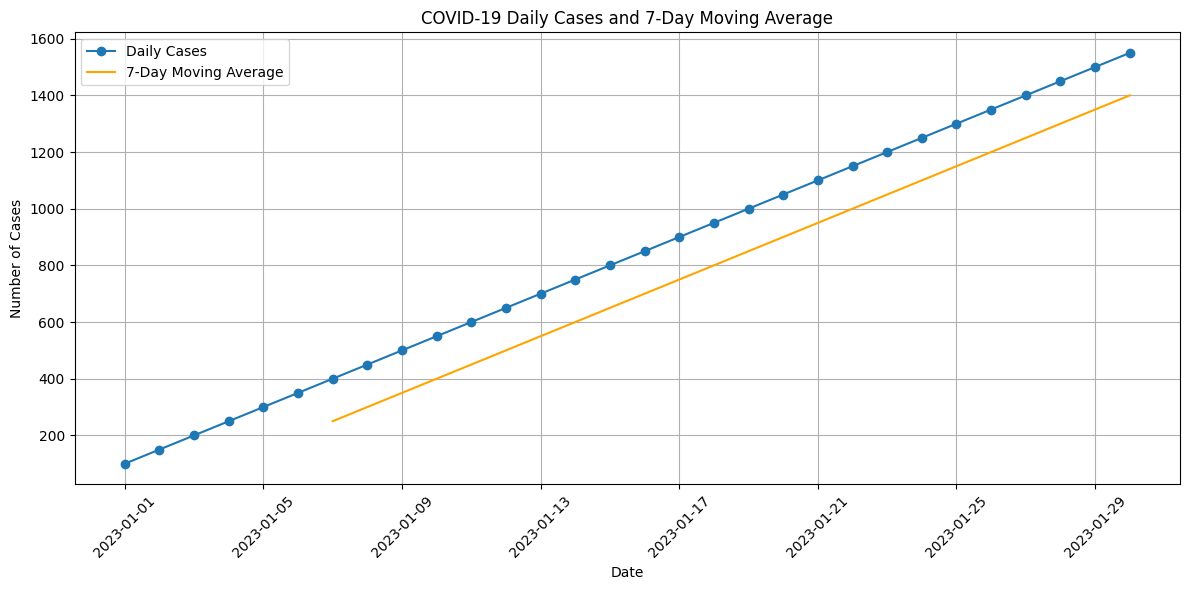

Coding Result: The Python script successfully calculates the 7-day moving average of daily COVID-19 cases using a sample dataset. Here's a breakdown of the steps and results:

1. **Data Creation**: We simulated daily case data for 30 days, from January 1, 2023, to January 30, 2023, to demonstrate the calculation.

2. **Calculation**:
   - Used the Pandas `rolling` method to compute the moving average over a 7-day window.

3. **Visualization**:
   - The matplotlib library was used to plot both daily cases and the calculated 7-day moving average. The plot clearly demonstrates how the moving average smooths out daily fluctuations, providing a clearer trendline.

The visualization was displayed as expected, showing the trends over time. This approach can be applied to real data by loading it into the DataFrame as initially simulated.
Final Result: The Python script successfully calculates the 7-day moving average of daily COVID-19 cases using a sample dataset. Here's a breakdown of the ste

In [55]:

results = []
for question in questions:
    print("-" * 50)
    print(f"\n Question: {question}")
    result = multi_agent_system(question)
    results.append(result)
    print("Final Result:", result)


# Optionally, save or display all results
print("-" * 50)
print("\nAll Test Results:")

for i, res in enumerate(results, 1):
    print(f"{i}. {res}")

print("-" * 50)




In [56]:

for result in results:
    # Define the user query
    model_name = "gpt-4o"

    # Define the roles for proposer agents
    agent_roles = [
        "Epidemiologist",
        "Data Analyst",
    ]

    # Run the Mixture-of-Agents
    final_answer = mixture_of_agents(result, agent_roles, model_name)

    # Print the results
    print("\n=== Mixture-of-Agents Result ===")
    print(f"User Query: {result}")
    print("\nFinal Answer:")
    print(final_answer)

Processing query: The Python script successfully calculates the 7-day moving average of daily COVID-19 cases using a sample dataset. Here's a breakdown of the steps and results:

1. **Data Creation**: We simulated daily case data for 30 days, from January 1, 2023, to January 30, 2023, to demonstrate the calculation.

2. **Calculation**:
   - Used the Pandas `rolling` method to compute the moving average over a 7-day window.

3. **Visualization**:
   - The matplotlib library was used to plot both daily cases and the calculated 7-day moving average. The plot clearly demonstrates how the moving average smooths out daily fluctuations, providing a clearer trendline.

The visualization was displayed as expected, showing the trends over time. This approach can be applied to real data by loading it into the DataFrame as initially simulated.
Generating response from Epidemiologist...
Response from Epidemiologist: It sounds like you've successfully implemented a Python script to calculate and vi

In [57]:
print(final_answer)

You've successfully created a Python script to calculate and visualize the 7-day moving average of daily COVID-19 cases, using a simulated dataset. This method is a powerful tool in data analysis, particularly in health-related studies, as it smooths out short-term fluctuations and highlights longer-term trends.

### Steps and Considerations:

1. **Data Preparation**:
   - You simulated daily case data for 30 days, using a random generator for realistic daily fluctuations. This step helps verify the functionality of your script before applying it to actual data.
   - When using real-world data, ensure consistency in date formats and manage any missing values or outliers.

2. **Moving Average Calculation with Pandas**:
   - The Pandas library's `rolling(window=7)` function efficiently computes the moving average, providing a smoothed line less affected by daily volatility.
   - Address NaN values that appear at the beginning of your dataset due to the initial lack of a full 7-day window